<a href="https://colab.research.google.com/github/phmlehau/TH_DeepLearning/blob/main/Lap2_TH_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
import pandas as pd
import numpy as np

# Data visualization packages
import matplotlib.pyplot as plt

# Keras / Tensorflow packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
# Lưu ý nâng cấp: KerasClassifier hiện tại thường được import từ scikit-learn qua scikeras nếu dùng bản mới
# from keras.wrappers.scikit_learn import KerasClassifier

# Model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Tải bộ mnist fashion dataset công khai
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()

# Kiểm tra kích thước ma trận dữ liệu ban đầu
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [3]:
# Chuyển đổi dữ liệu ảnh từ dạng 3D (Số lượng, 28, 28) sang 2D (Số lượng, 784) để đưa vào mạng ANN phẳng
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# Chuẩn hóa dữ liệu về khoảng [0, 1] bằng MinMaxScaler
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

# Kiểm tra các lớp phân loại dữ liệu đầu ra
print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


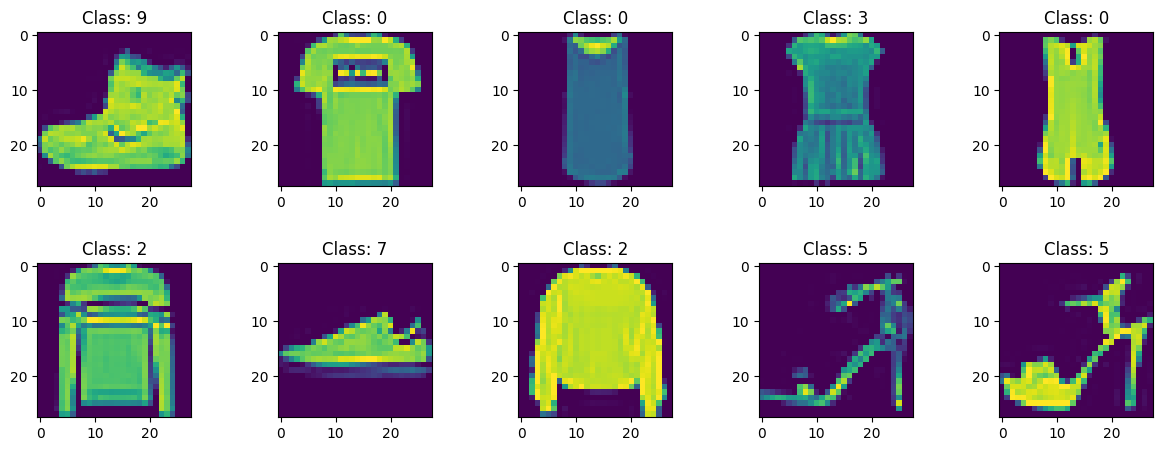

In [4]:
# Tạo khung vẽ 2 hàng, 5 cột để hiển thị 10 hình ảnh đầu tiên
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text("Class: " + str(y_train[i]))

plt.subplots_adjust(hspace=0.5)
plt.show()

In [5]:
# Khởi tạo mô hình tuần tự mạng Neural Network đám phẳng
fashion_model = Sequential()

# Thêm tầng ẩn đầu tiên (Hidden Layer) với 256 Nodes và hàm kích hoạt ReLU
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm tầng đầu ra (Output Layer) có 10 phân lớp tương ứng với hàm Softmax tính xác suất mẫu
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình với thuật toán tối ưu Adam và hàm lỗi Sparse Categorical Crossentropy
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị cấu trúc tóm tắt mạng cấu hình tham số
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Tiến hành khớp dữ liệu huấn luyện, trích xuất 10% làm tập đánh giá kiểm thử validation qua 20 epochs
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8225 - loss: 0.5044 - val_accuracy: 0.8538 - val_loss: 0.4045
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8658 - loss: 0.3705 - val_accuracy: 0.8580 - val_loss: 0.3722
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8790 - loss: 0.3307 - val_accuracy: 0.8743 - val_loss: 0.3408
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8865 - loss: 0.3077 - val_accuracy: 0.8777 - val_loss: 0.3408
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8929 - loss: 0.2909 - val_accuracy: 0.8797 - val_loss: 0.3411
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8981 - loss: 0.2744 - val_accuracy: 0.8763 - val_loss: 0.3589
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9033 - loss: 0.2610 - val_accuracy: 0.8845 - val_loss: 0.3319
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9058 - loss: 0.2520

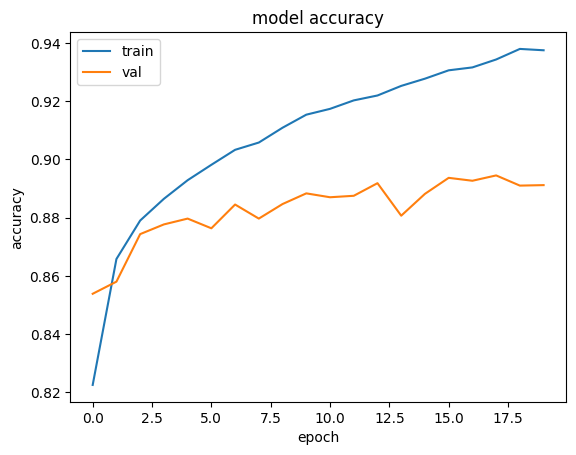

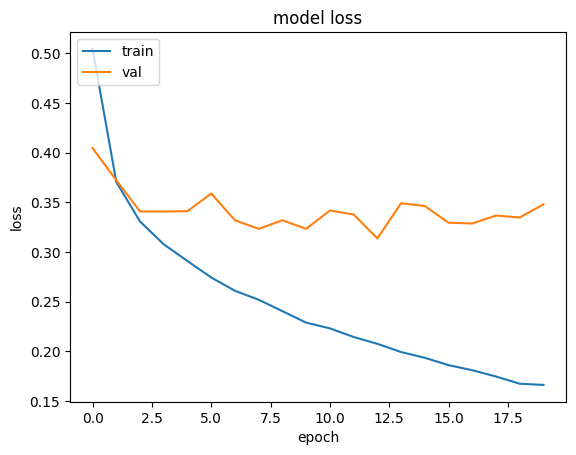

In [7]:
# Vẽ đồ thị biểu diễn Độ chính xác (Accuracy) qua các vòng lặp epochs
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Vẽ đồ thị biểu diễn Độ mất mát (Loss) qua các vòng lặp epochs
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [8]:
# Dự đoán nhãn cho ảnh ở vị trí index 0 và index 10 trên tập X_test
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [9]:
# Khai báo đường dẫn lưu trữ các file CSV
mnist_train_path = '/content/sample_data/fashion-mnist_train.csv'
mnist_test_path = '/content/sample_data/fashion-mnist_test.csv'

# Đọc file bằng pandas
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

# Tách cột thuộc tính (X) và cột nhãn mục tiêu (y)
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]
y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print("Kích thước X_train sau khi lấy từ CSV:", X_train.shape)
print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

# Khởi tạo kiến trúc mô hình tương tự để chạy lại tập dữ liệu này
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Huấn luyện trên cấu hình mới chạy trong 30 epochs
model_fit_csv = model.fit(X_train, y_train, epochs=30, verbose=1)

# In thử nghiệm dự đoán
print(np.argmax(model.predict(X_test)[0]), y_test[0])

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/fashion-mnist_train.csv'